# Top

In [1]:
%matplotlib inline
%load_ext autoreload
import sys

sys.path.append("../")
sys.path.append("/app")

from verimon.analysis import *

experiment_dir = (
    "../stats/exp-2025-11-24_16-54-26-comp-base-premise-prem_sam-snl_sam-snl/"
)
experiment_data = load_experiment_data(experiment_dir)

add_learning_rounds(experiment_data)

experiment_data = combine_sampling_and_verimon(
    experiment_data,
    [
        "file",
        "parameters",
        "horizon",
        "use_random_eq",
        "verimon_walks_per_state",
        "old_walks_per_state",
    ],
)
symbols, colors = add_symbol_color(experiment_data, color_map=None)

clean_data(experiment_data)

add_short_names(experiment_data)


experiments_in_legends = False
save_figures = True
save_path = "../VerifiableMonitorsTex/inprogress/images/plots"
verimon_data = [d for d in experiment_data if "verimon" in d]

plot_kwargs = {
    "fillstyle": "none",
    "markeredgewidth": 1,
    "markersize": 4,
}

Error in 2025-11-24_16-54-26_hidden_incentive_(horizon=11,slack=[0, 0]).json: std::bad_alloc
Loaded 247/277/-2 (89.82%) JSON files from ../stats/exp-2025-11-24_16-54-26-comp-base-premise-prem_sam-snl_sam-snl/


In [2]:
import os

os.system(f"grep -r 'WARNING' {experiment_dir}/logs/*")
os.system(f"grep -r 'ERROR' {experiment_dir}/logs/*")
os.system(
    f'grep -h "quotient:" {experiment_dir}/logs/*'
    + r""" | sed 's/.*quotient: \([0-9]\+\) states.*/\1/' | awk '{sum+=$1; n+=1; if(min==""){min=$1}; if($1>max){max=$1}; if($1<min){min=$1}} END{printf "min=%d, avg=%.2f, max=%d\n", min, sum/n, max}'"""
)
os.system(
    f'grep -h "quotient:" {experiment_dir}/logs/*'
    + r""" | sed 's/.*family size: \([0-9e+]\+\).*/\1/' | awk '{val=$1+0; sum+=val; c++; if(NR==1){min=val; max=val} else {if(val>max){max=val}; if(val<min){min=val}}} END{printf "min=%.0f, avg=%.2f, max=%.0f\n", min, sum/c, max}'"""
)
longest_experiment = max(experiment_data, key=lambda x: x["time"]["total"])
print(
    f"Longest experiment {longest_experiment['experiment']['name']} {longest_experiment['experiment']['variant']} took {longest_experiment['time']['total']:.2f}s ({longest_experiment['time']['total'] / 60:.2f} min ({longest_experiment['time']['total'] / (60 * 60):.2f} h))."
)

../stats/exp-2025-11-24_16-54-26-comp-base-premise-prem_sam-snl_sam-snl//logs/2025-11-24_16-54-26_hidden_incentive_(horizon=11,slack=[0, 0]).log:ERROR:2025-11-25 04:17:19,081 - (2457.40s) - experiment.py:264 - Error in Verimon: Traceback (most recent call last):
min=8, avg=2512.33, max=16109
min=2, avg=1807954846028144574464.00, max=999999999999999983222784
Longest experiment airport (file=airportB-3.nm,parameters={'constants': 'DMAX=3,PMAX=3'},horizon=11,slack=[0.2, 0.05]) took 42803.17s (713.39 min (11.89 h)).


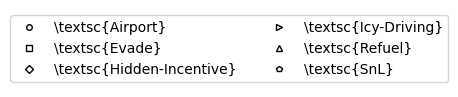

In [3]:
import matplotlib.backend_bases
from matplotlib.backends.backend_pgf import FigureCanvasPgf

matplotlib.backend_bases.register_backend("pdf", FigureCanvasPgf)

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

name_map = {
    "airport": r"\textsc{Airport}",
    "evade": r"\textsc{Evade}",
    "refuel": r"\textsc{Refuel}",
    "icy-driving": r"\textsc{Icy-Driving}",
    "hidden_incentive": r"\textsc{Hidden-Incentive}",
    "snakes_ladders": r"\textsc{SnL}",
}
legend_elements = {}
for data in verimon_data:
    if data["experiment"]["name"] not in legend_elements:
        legend_elements[data["experiment"]["name"]] = mlines.Line2D(
            [],
            [],
            linewidth=0,
            color=data["color"],
            marker=data["symbol"],
            **plot_kwargs,
            label=f"{name_map[data['experiment']['name']]}",
        )

# Create a legend for the symbols and colors
# legend_elements = [
#     mlines.Line2D(
#         [],
#         [],
#         linewidth=0,
#         color=data["color"],
#         marker=data["symbol"],
#         label=f"({data['experiment']['short_name']}) {data['experiment']['name']} {data['experiment']['variant']}",
#     )
#     for data in verimon_data
# ]

plt.legend(handles=legend_elements.values(), loc="center", ncol=2)
plt.axis("off")
plt.gcf().set_size_inches(2, 1)
if save_figures:
    plt.savefig(f"{save_path}/legend.pgf", bbox_inches="tight")
plt.show()

generate_learn_table(verimon_data, True, save_path, "experiments")

# Compare runtimes of verimon and traditional learning

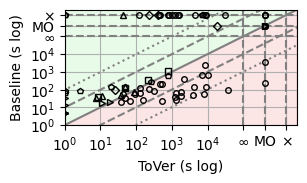

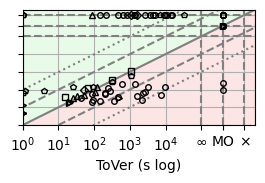

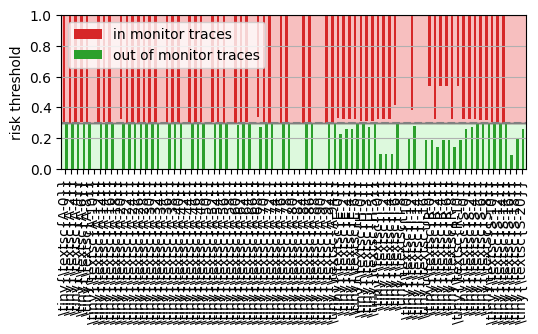

/home/luko/Documents/ToVer-project/ToVer/verimon/analysis.py:1056: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


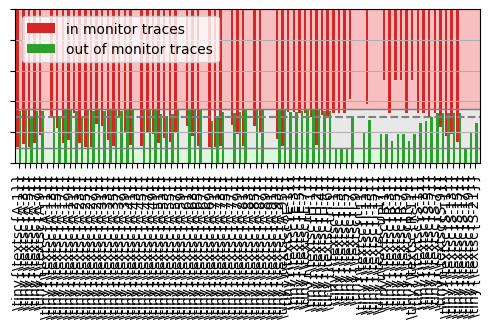

/home/luko/Documents/ToVer-project/ToVer/verimon/analysis.py:1056: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


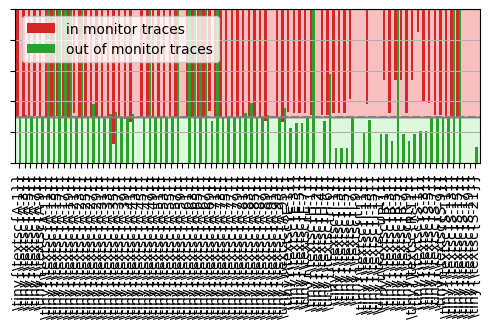

In [4]:
from verimon.analysis import *

verimon_data_with_slack = [
    d for d in verimon_data if float(d["experiment"]["fp_slack"]) > 0
]
verimon_data_no_slack = [
    d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0
]
compare_runtimes(
    verimon_data_with_slack,
    "verimon",
    "sampling",
    figsize=(3, 1.5),
    # figsize=(6, 4),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="runtimes_with_slack",
    plot_kwargs=plot_kwargs,
)
compare_runtimes(
    verimon_data_no_slack,
    "verimon",
    "sampling",
    figsize=(3, 1.5),
    # figsize=(6, 4),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="runtimes_no_slack",
    show_y_axis=False,
    plot_kwargs=plot_kwargs,
)
# compare_thresholds(verimon_data, "verimon", "sampling", colors)
compare_thresholds_bar(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0],
    ["verimon"],
    "name",
    lambda d: f"\\tiny{{{d['experiment']['short_name']}}}",
    0.3,
    fig_size=(6, 2),
    # fig_size=(10, 5),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="thresholds_tover_no_slack",
)
compare_thresholds_bar(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0.2],
    ["verimon"],
    "name",
    lambda d: f"\\tiny{{{d['experiment']['short_name']}}}",
    0.3,
    0.05,
    0.2,
    fig_size=(6, 2),
    # fig_size=(10, 5),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="thresholds_tover_slack",
    show_y_axis=False,
)

compare_thresholds_bar(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0.2],
    ["sampling"],
    "name",
    lambda d: f"\\tiny{{{d['experiment']['short_name']}}}",
    0.3,
    bundle=1,
    fig_size=(6, 2),
    # fig_size=(10, 5),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="theresholds_sampling",
    show_y_axis=False,
)

# Compare learned monitor sizes

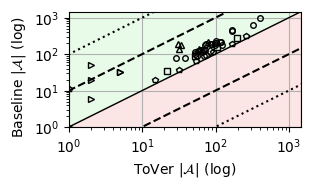

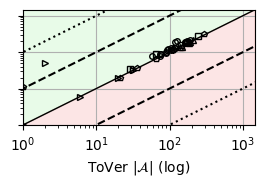

In [5]:
from verimon.analysis import *


compare_monitor_sizes(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0.2],
    "verimon",
    "sampling",
    figsize=(3, 1.5),
    # figsize=(6, 4),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="monitor_sizes_with_slack",
    plot_kwargs=plot_kwargs,
)
compare_monitor_sizes(
    [d for d in verimon_data if float(d["experiment"]["fp_slack"]) == 0],
    "verimon",
    "sampling",
    figsize=(3, 1.5),
    # figsize=(6, 4),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="monitor_sizes_no_slack",
    show_y_axis=False,
    plot_kwargs=plot_kwargs,
)

# Runtime by parameters

/home/luko/Documents/ToVer-project/ToVer/verimon/analysis.py:1137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_func, xs, ys, p0=(1, 0.1))
/home/luko/Documents/ToVer-project/ToVer/verimon/analysis.py:1134: RuntimeWarning: overflow encountered in exp
  return a * np.exp(b * x)
/home/luko/.cache/pypoetry/virtualenvs/verimon-AKvrCngx-py3.13/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:1024: RuntimeWarning: overflow encountered in square
  cost = np.sum(infodict['fvec'] ** 2)
/home/luko/.cache/pypoetry/virtualenvs/verimon-AKvrCngx-py3.13/lib/python3.13/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


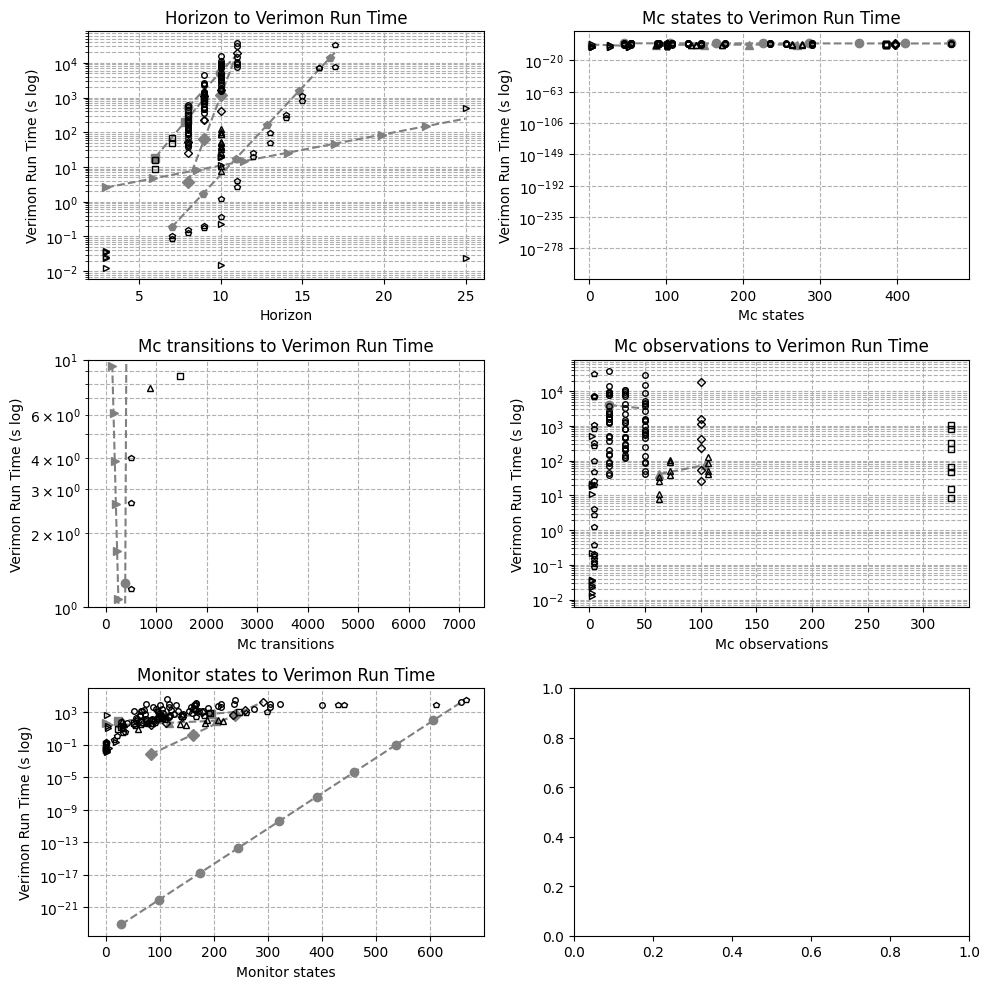

In [6]:
parameters = [
    ("experiment", "horizon", "log"),
    ("mc", "mc_states", "log"),
    ("mc", "mc_transitions", "log"),
    ("mc", "mc_observations", "log"),
    ("verimon", "monitor_states", "log"),
]

runtime_by_params(
    [data for data in experiment_data if "verimon" in data],
    "verimon",
    parameters,
    experiments_in_legends=experiments_in_legends,
    plot_kwargs=plot_kwargs,
    fit_line=True,
)

# Compare horizon on and off in snakes and ladders data

In [7]:
# # Filter data for snakes and ladders experiments
# snakes_ladders_data = sorted(
#     [
#         data
#         for data in experiment_data
#         if data["experiment"]["name"] == "snakes_ladders"
#     ],
#     key=lambda x: x["experiment"]["horizon"],
# )

# # Separate data based on use_horizon_in_filtering
# horizon_on_data = [
#     data
#     for data in snakes_ladders_data
#     if data["experiment"]["use_horizon_in_filtering"]
# ]
# horizon_off_data = [
#     data
#     for data in snakes_ladders_data
#     if not data["experiment"]["use_horizon_in_filtering"]
# ]

# # Extract monitor sizes
# horizon_on_trad_sizes = [data["sampling"]["monitor_states"] for data in horizon_on_data]
# horizon_on_verimon_sizes = [
#     data["verimon"]["monitor_states"] for data in horizon_on_data
# ]
# horizon_off_trad_sizes = [
#     data["sampling"]["monitor_states"] for data in horizon_off_data
# ]
# horizon_off_verimon_sizes = [
#     data["verimon"]["monitor_states"] for data in horizon_off_data
# ]

# # Horizon sizes for x-axis labels
# horizon_on_names = [data["experiment"]["horizon"] for data in horizon_on_data]
# horizon_off_names = [data["experiment"]["horizon"] for data in horizon_off_data]

# bar_width = 1 / 4 - 0.05
# index_on = range(len(horizon_on_data))
# index_off = range(len(horizon_off_data))

# # Plot for use_horizon_in_filtering = True
# plt.bar(
#     index_on,
#     horizon_on_trad_sizes,
#     bar_width,
#     label="Traditional (Horizon On)",
#     color="blue",
# )
# plt.bar(
#     [i + bar_width for i in index_on],
#     horizon_on_verimon_sizes,
#     bar_width,
#     label="Verimon (Horizon On)",
#     color="cyan",
# )

# # Plot for use_horizon_in_filtering = False
# plt.bar(
#     [i + 2 * bar_width for i in index_off],
#     horizon_off_trad_sizes,
#     bar_width,
#     label="Traditional (Horizon Off)",
#     color="red",
# )
# plt.bar(
#     [i + 3 * bar_width for i in index_off],
#     horizon_off_verimon_sizes,
#     bar_width,
#     label="Verimon (Horizon Off)",
#     color="orange",
# )

# plt.xlabel("Experiment Variants")
# plt.ylabel("Number of States in Monitor")
# plt.title(
#     "Comparison of Monitor Sizes: Traditional vs Verimon (Horizon On vs Horizon Off)"
# )
# plt.xticks(
#     [i + bar_width * 3 / 2 for i in index_on],
#     horizon_on_names,
# )
# plt.legend()
# plt.yscale("log")

# plt.tight_layout()
# plt.show()

# # Plot for use_horizon_in_filtering = True
# # Interleave horizon on and off data
# interleaved_data = []
# for on, off in zip(horizon_on_data, horizon_off_data):
#     interleaved_data.append(on)
#     interleaved_data.append(off)

# compare_thresholds_bar(
#     interleaved_data,
#     ["verimon", "sampling"],
#     "horizon",
#     lambda d: f"{d['experiment']['horizon']} - {'use' if d['experiment']['use_horizon_in_filtering'] else 'not use'}",
#     0.3,
#     0.05,
#     0.2,
# )

# Compare thresholds and amount of samples

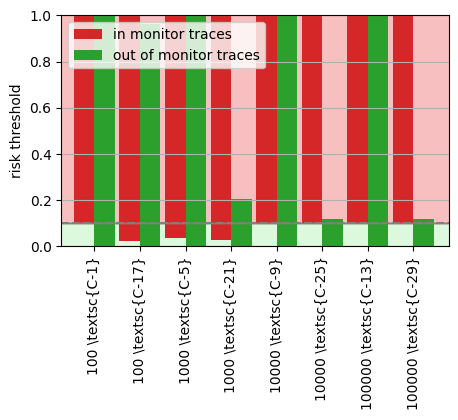

/home/luko/Documents/ToVer-project/ToVer/verimon/analysis.py:1056: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


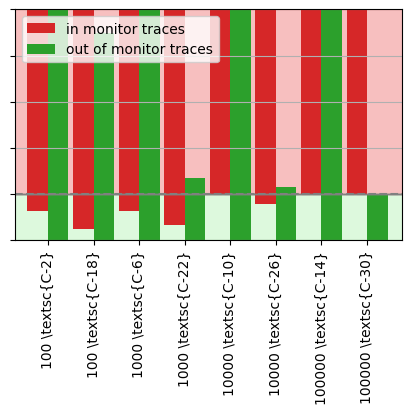

/home/luko/Documents/ToVer-project/ToVer/verimon/analysis.py:1056: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" for _ in ax.get_yticks()])


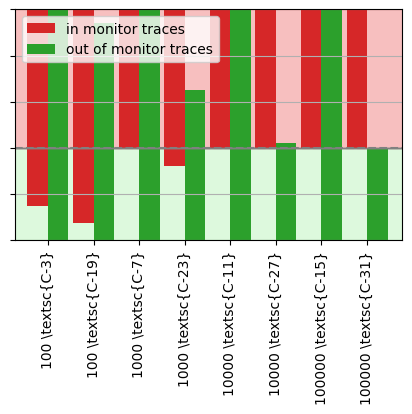

In [8]:
compare_trad_data_low_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.1
            or data["experiment"]["threshold"] == Fraction(1, 10)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)
compare_trad_data_mid_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.2
            or data["experiment"]["threshold"] == Fraction(1, 5)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)
compare_trad_data_high_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.4
            or data["experiment"]["threshold"] == Fraction(2, 5)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)

compare_thresholds_bar(
    compare_trad_data_low_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    threshold=0.1,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_low",
)
compare_thresholds_bar(
    compare_trad_data_mid_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    threshold=0.2,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_mid",
    show_y_axis=False,
)
compare_thresholds_bar(
    compare_trad_data_high_threshold,
    ["sampling"],
    "amount of traces in sampling",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['short_name']}",
    threshold=0.4,
    fig_size=(5, 3),
    experiments_in_legends=experiments_in_legends,
    save_figures=save_figures,
    save_path=save_path,
    file_name="sampling_thresholds_high",
    show_y_axis=False,
)

# Relative time spent in paynt, product generator and other

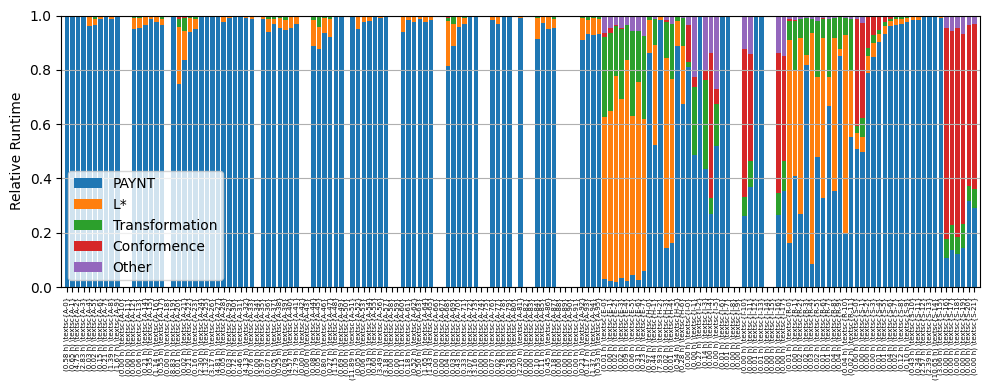

In [9]:
import numpy as np


filtered_data = [
    data for data in experiment_data if data["experiment"]["name"] != "compare-trad"
]
product_times = [
    (
        data["verimon"]["product_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
paynt_times = [
    (
        data["verimon"]["paynt_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
eq_times = [
    (
        data["verimon"]["eq_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
lstar_times = [
    (
        data["verimon"]["lstar_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
other_times = [
    (
        1
        - (
            data["verimon"]["product_time"]
            + data["verimon"]["paynt_time"]
            + data["verimon"]["eq_time"]
            + data["verimon"]["lstar_time"]
        )
        / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]

if experiments_in_legends:
    experiment_names = [
        f"{data['experiment']['name']}\n{data['experiment']['variant']}\n({data['time']['total'] / (60 * 60):.2f} h)"
        for data in filtered_data
    ]
else:
    experiment_names = [
        f"({data['time']['total'] / (60 * 60):.2f} h) {data['experiment']['short_name']}"
        for data in filtered_data
    ]

plt.figure(figsize=(7, 3))
index = range(len(filtered_data))
bottom = np.zeros(len(filtered_data))


plt.bar(index, paynt_times, width=0.8, label="PAYNT")
bottom += paynt_times
plt.bar(index, lstar_times, bottom=bottom, width=0.8, label="L*")
bottom += lstar_times
plt.bar(index, product_times, bottom=bottom, width=0.8, label="Transformation")
bottom += product_times
plt.bar(
    index,
    eq_times,
    bottom=bottom,
    width=0.8,
    label="Conformence",
)
bottom += eq_times
plt.bar(
    index,
    other_times,
    bottom=bottom,
    width=0.8,
    label="Other",
)

plt.ylabel("Relative Runtime")
plt.xticks(index, experiment_names, rotation=90, fontsize=5)
plt.legend(loc="lower left")
plt.xlim(-1, len(filtered_data))
plt.ylim(0, 1)

fig = plt.gcf()
fig.set_size_inches(10, 4)

plt.tight_layout()
plt.grid(axis="y")
if save_figures:
    plt.savefig(f"{save_path}/verimon_times.pgf", bbox_inches="tight")
plt.show()

In [10]:
from verimon.analysis import runtime_from_logs

sorted_experiment_data = sorted(
    experiment_data, key=lambda d: d["time"]["total"], reverse=True
)
for data in experiment_data:
    if "verimon" in data:
        print(
            "\n",
            data["experiment"]["name"],
            data["experiment"]["variant"],
            data["time"]["total"],
        )
        print(data["log_path"].replace("../", "./"))
        times, example_msg = runtime_from_logs(data["log_path"])
        print(
            "\n".join(
                map(
                    lambda t: f"{t[0]} ({t[1]}): {example_msg[t[0]]}",
                    sorted(times.items(), key=lambda x: x[1], reverse=True)[:5],
                )
            )
        )


 airport (file=airportA-3.nm,parameters={'constants': 'DMAX=3,PMAX=3'},horizon=10,slack=[0, 0]) 2074.836304664612
./stats/exp-2025-11-24_16-54-26-comp-base-premise-prem_sam-snl_sam-snl//logs/2025-11-24_16-54-26_airport_(file=airportA-3.nm,parameters={'constants': 'DMAX=3,PMAX=3'},horizon=10,slack=[0, 0]).log
generator.py:200 (1472.08): no counterexamples above threshold
generator.py:190 (591.4): counterexample found: A(2,0)={d:2,pobs:2,turn:0}, A(3,0)={d:2,pobs:1,turn:1}, A(4,0)={d:1,pobs:1,turn:0}, A(5,0)={d:1,pobs:1,turn:1}, A(6,0)={d:0,pobs:1,turn:0}, A(7,0)=end, A(8,0)={d:0,pobs:0,turn:1}, A(9,0)={d:0,pobs:0,turn:0}, A(10,0)={d:1,pobs:1,turn:0}, A(11,0)=end, A(12,0)={d:0,pobs:2,turn:1}, A(13,0)=end, A(14,0)={d:0,pobs:1,turn:0}, A(15,0)={d:0,pobs:0,turn:0} (None)
MonitorLearning.py:280 (9.4): Finding counterexample for hypothesis with 1 states
verify.py:182 (0.8800000000000003): Unrolling done
verify.py:203 (0.31): creating product done

 airport (file=airportA-3.nm,parameters={'co